In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

dates = pd.date_range(start='2023-01-01' , periods=365,freq='D')
values = [100+ i + 10*np.sin(2*np.pi*i/30) + np.random.randn()*5 for i in range(365)]

In [6]:
print(np.sin(2*np.pi*1/30))
print(np.sin(2*np.pi*2/30))
print(np.sin(2*np.pi*3/30))

0.20791169081775931
0.40673664307580015
0.5877852522924731


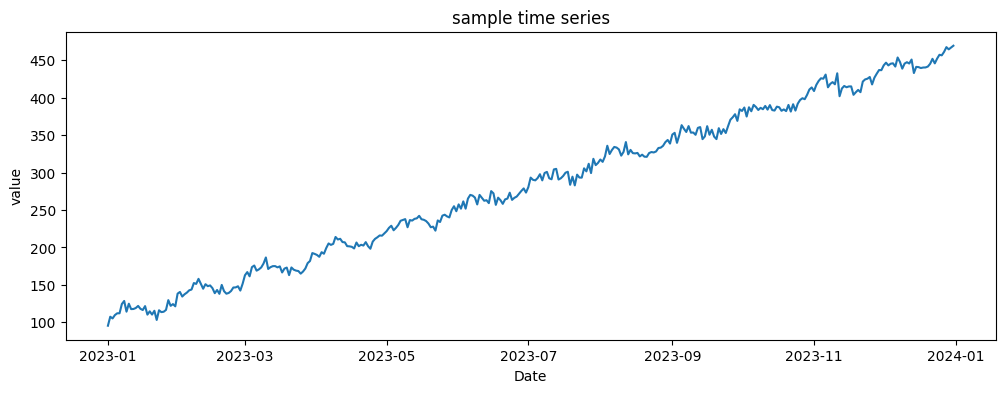

In [7]:
ts = pd.Series(values,index=dates)
plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title('sample time series')
plt.xlabel('Date')
plt.ylabel('value')
plt.show()

In [8]:
np.arange(2)

array([0, 1])

In [10]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.6 MB 12.1 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.6 MB 12.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 12.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 11.1 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 9.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 7.0 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]

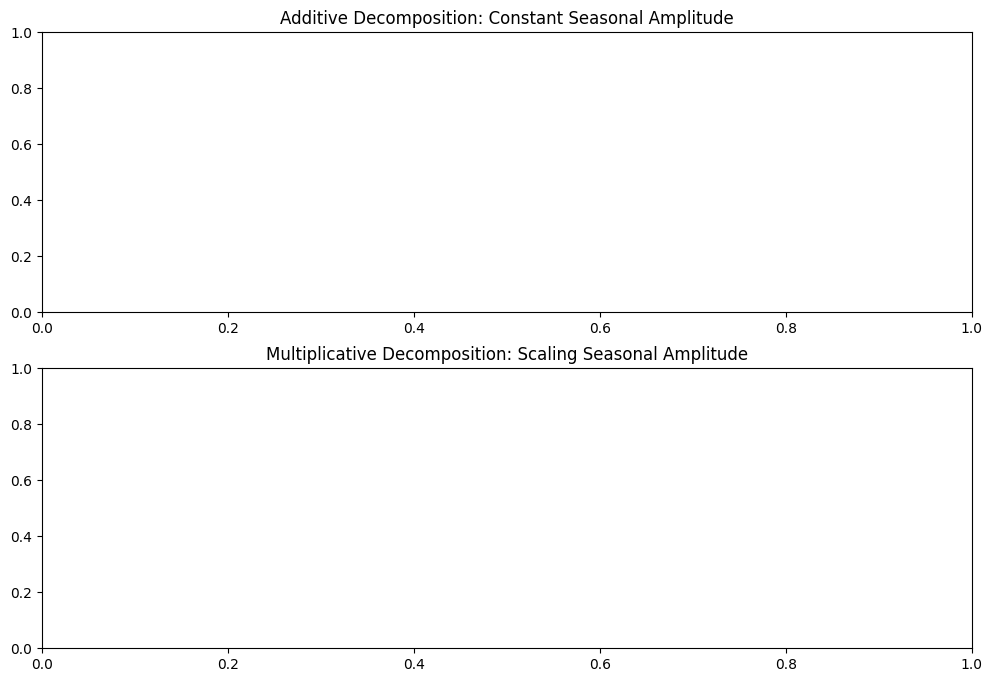

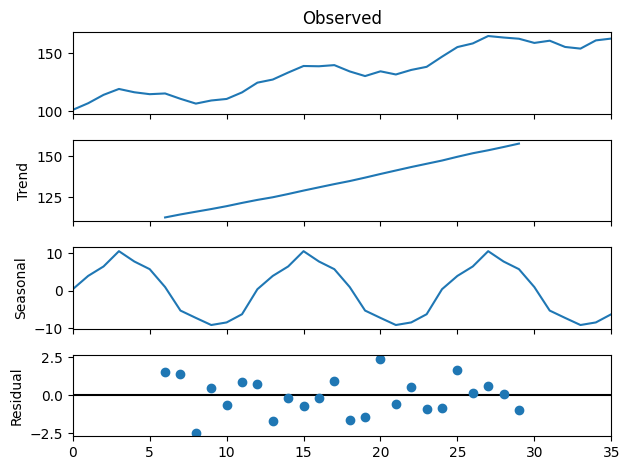

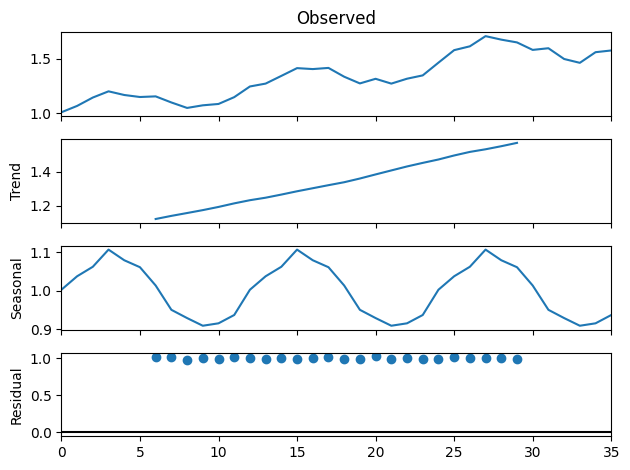

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Set seed for reproducibility
np.random.seed(42)

# Create 3 years of monthly data
months = 36
time = np.arange(months)

# Trend: Linear increase
trend = 100 + 2 * time

# Seasonal pattern (yearly cycle)
seasonal = 10 * np.sin(2 * np.pi * time / 12)

# Noise
noise = np.random.randn(months) * 2

# Additive model: Seasonal amplitude is constant
additive_series = trend + seasonal + noise

# Multiplicative model: Seasonal amplitude scales with trend
# (seasonal effect is 10% of current level)
multiplicative_series = (trend / 100) * (1 + seasonal / 100) * (1 + noise / 100)

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Additive
decomp_add = seasonal_decompose(additive_series, model='additive', period=12)
decomp_add.plot()
axes[0].set_title('Additive Decomposition: Constant Seasonal Amplitude')
plt.tight_layout()

# Multiplicative  
decomp_mult = seasonal_decompose(multiplicative_series, model='multiplicative', period=12)
decomp_mult.plot()
axes[1].set_title('Multiplicative Decomposition: Scaling Seasonal Amplitude')
plt.tight_layout()

plt.show()

# Key observation: In multiplicative, seasonal component varies with trend level

In [2]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

data = np.cumsum(np.random.randn(100))

result = adfuller(data)

print(f'adf statistic : {result[0]:.4f}')
print(f'P-value : {result[1]:.4f}')

if result[1] <0.05:
    print("stationary")
else:
    print("Non -stationary -differencing needed")

adf statistic : -2.2349
P-value : 0.1938
Non -stationary -differencing needed


C:\Users\damod\AppData\Local\Temp\ipykernel_792\2302457009.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(monthly_data, labels=['Jan','Feb','Mar','Apr','May','Jun',


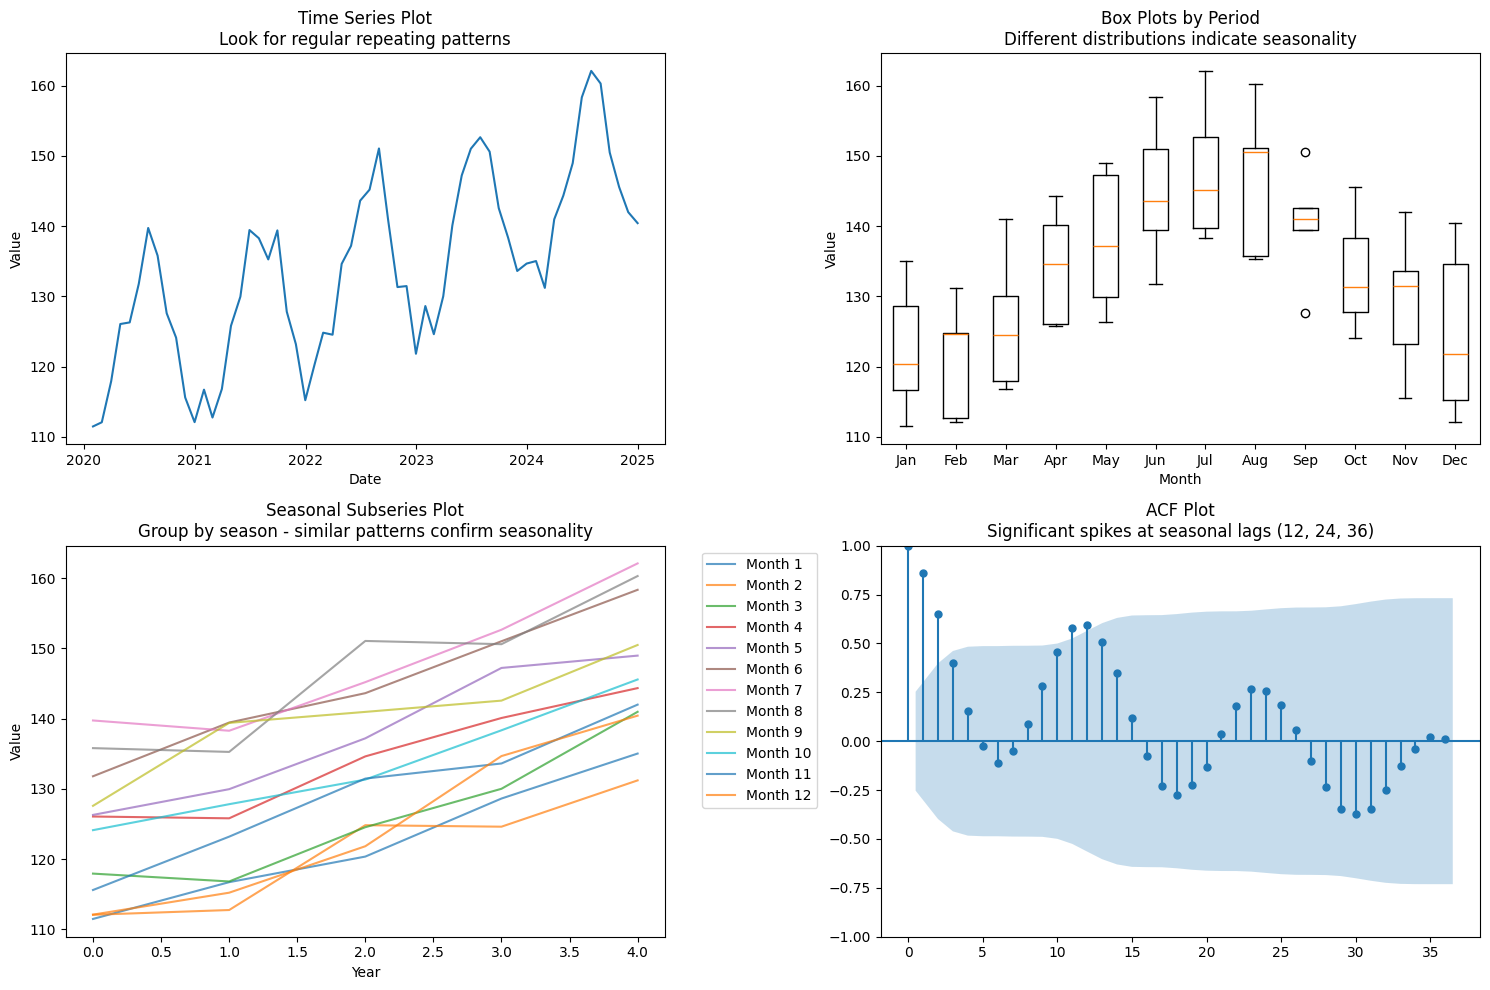

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Generate seasonal time series data (5 years monthly)
np.random.seed(42)
years = 5
months = years * 12
dates = pd.date_range(start='2020-01-01', periods=months, freq='ME')

# Trend: slight upward
trend = 100 + 0.5 * np.arange(months)

# Seasonal pattern (monthly)
seasonal_pattern = np.array([10, 12, 15, 20, 25, 30, 32, 30, 25, 18, 12, 8])
seasonal = np.tile(seasonal_pattern, years)

# Noise
noise = np.random.randn(months) * 3

# Combine
data = trend + seasonal + noise
ts = pd.Series(data, index=dates)

# 1. Time Series Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(ts)
axes[0,0].set_title('Time Series Plot\nLook for regular repeating patterns')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Value')

# 2. Seasonal Subseries Plot
# Group by month and plot each month's values
monthly_data = [ts[ts.index.month == m].values for m in range(1, 13)]
axes[0,1].boxplot(monthly_data, labels=['Jan','Feb','Mar','Apr','May','Jun',
                                         'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0,1].set_title('Box Plots by Period\nDifferent distributions indicate seasonality')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Value')

# 3. Seasonal Subseries Plot (line version)
for m in range(1, 13):
    month_data = ts[ts.index.month == m]
    axes[1,0].plot(range(len(month_data)), month_data.values, 
                   label=f'Month {m}', alpha=0.7)
axes[1,0].set_title('Seasonal Subseries Plot\nGroup by season - similar patterns confirm seasonality')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Value')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. ACF Plot
plot_acf(ts, lags=36, ax=axes[1,1])
axes[1,1].set_title('ACF Plot\nSignificant spikes at seasonal lags (12, 24, 36)')

plt.tight_layout()
plt.show()

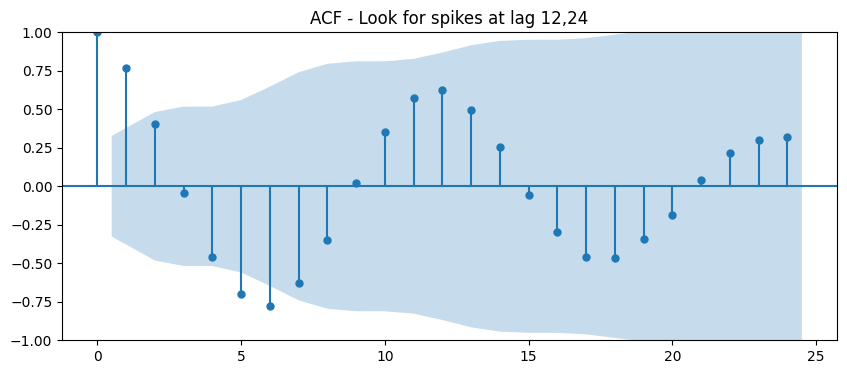

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
months = 36
seasonal_pattern = [10, 12, 15, 20, 25, 30, 32, 30, 25, 18, 12, 8] 
data = [seasonal_pattern[i%12] + np.random.randn()*2 for i in range(months)]

fig , ax = plt.subplots(figsize=(10,4))
plot_acf(data,lags=24,ax=ax)
plt.title('ACF - Look for spikes at lag 12,24')
plt.show()

In [9]:
import numpy as np
import pandas as pd

t = np.arange(10)
trend_data = 50 + 2*t + np.random.randn(10)*5

differenced = np.diff(trend_data)
print(f"Original mean: {trend_data.mean():.2f}")  # Changes over time
print(f"Differenced mean: {differenced.mean():.2f}")

Original mean: 59.51
Differenced mean: 2.77


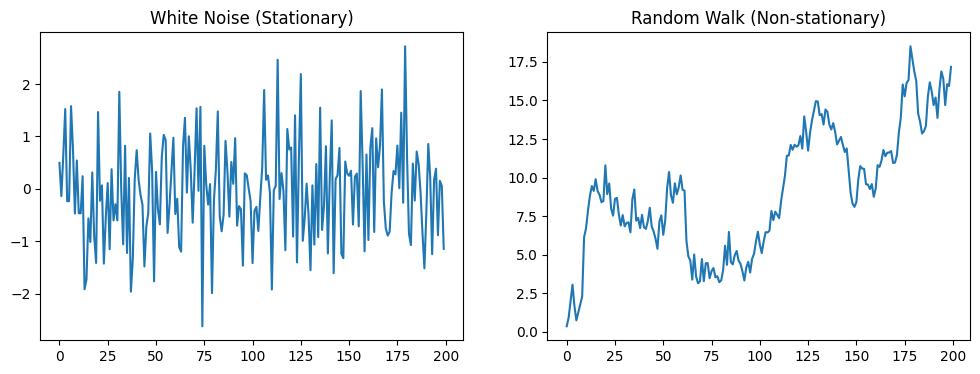

In [10]:

import numpy as np
import matplotlib.pyplot as plt

# Pipeline: Generate both -> Plot -> Compare ACF patterns

np.random.seed(42)
n = 200

# White Noise
white_noise = np.random.randn(n)

# Random Walk (cumulative sum of white noise)
random_walk = np.cumsum(np.random.randn(n))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(white_noise)
axes[0].set_title('White Noise (Stationary)')

axes[1].plot(random_walk)
axes[1].set_title('Random Walk (Non-stationary)')
plt.show()

# Key observation: Random walk "wanders" far from origin; white noise stays bounded



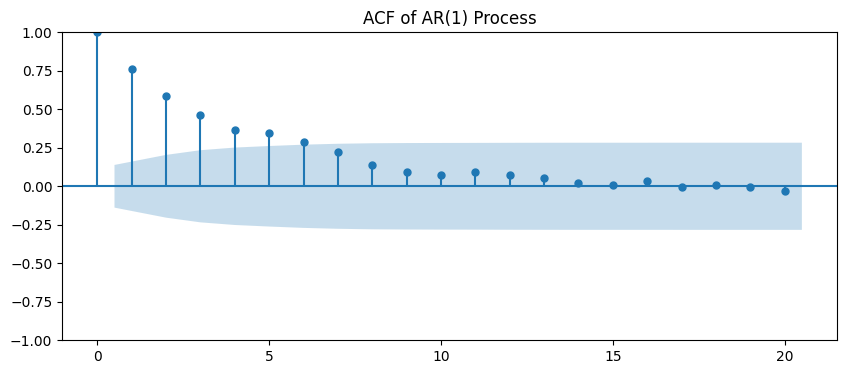

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n =  200
y  =np.zeros(n)
for t in range(1,n):
    y[t] = 0.8* y[t-1] + np.random.randn()
    
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(y, lags=20, ax=ax)
plt.title('ACF of AR(1) Process')
plt.show()

In [19]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Pipeline: Create trending data -> Difference -> Verify stationarity

# Step 1: Non-stationary data (random walk)
np.random.seed(42)
random_walk = np.cumsum(np.random.randn(100))

# Step 2: Apply first difference
differenced = np.diff(random_walk)

# Step 3: Test stationarity
def adf_test(data, name):
    result = adfuller(data)
    print(f"{name}: ADF={result[0]:.2f}, p-value={result[1]:.4f}")

adf_test(random_walk, "Original")      # p > 0.05 (non-stationary)
adf_test(differenced, "Differenced")

Original: ADF=-1.36, p-value=0.6021
Differenced: ADF=-10.01, p-value=0.0000


In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

dates = pd.date_range(start='2023-01-01',periods=365,freq='D')
dates

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', length=365, freq='D')

In [ ]:
values = [100 + 0.5*i + 10*np.sin(2*np.pi*i/30) + np.random.randn()*5 for i in range(365)]
values

C:\Users\damod\AppData\Local\Temp\ipykernel_792\2302457009.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(monthly_data, labels=['Jan','Feb','Mar','Apr','May','Jun',


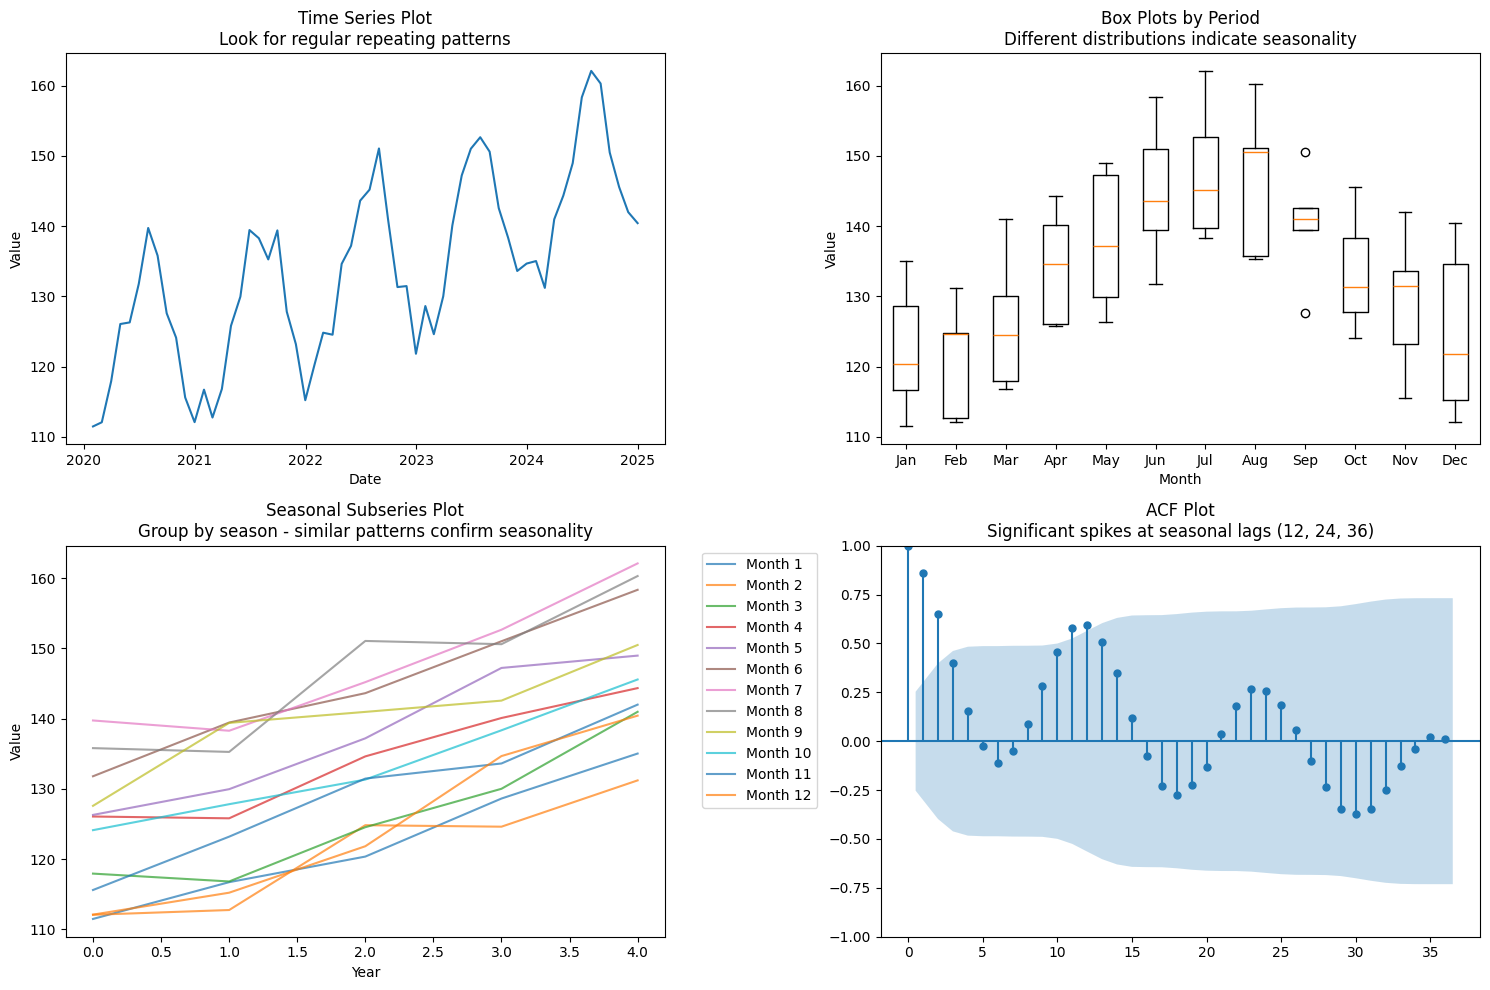